<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/We_logo.svg/3840px-We_logo.svg.png" alt="WE Logo" width="60" style="margin-bottom:8px"/>

# Telecom Egypt (WE) — ML Project
## Smart Plan Recommendation System

---

### Background

Telecom Egypt (WE) serves thousands of subscribers across Egypt with internet plans that vary in speed, quota, and price. A key business challenge is **plan-subscriber mismatch** — subscribers enrolled in plans that do not reflect their actual usage and payment behavior.

This project simulates a real-world data science task at WE. You are part of the Data & AI team. Your mission is to build a machine learning model that analyzes subscriber profiles and recommends the most suitable plan action:

> **Upgrade** — the subscriber needs a bigger plan  
> **Downgrade** — the subscriber is over-paying for what they use  
> **Keep** — the current plan is a good fit

---

### Available Datasets

| Dataset | Description |
|---------|-------------|
| `Customer.csv` | Subscriber demographics and plan enrollment |
| `Subscription_Plan_Lkp.csv` | Plan details — quota, speed, and price |
| `Network_Elements.csv` | Infrastructure type per subscriber (VDSL, FTTH, etc.) |
| `Payments.csv` | Monthly payment transactions per subscriber |
| `Consumption_RG_LKP.csv` | Lookup table for consumption rating groups |

---

### General Instructions

- Read each step carefully before writing any code.
- Each step has a clear objective — understand **why** you are doing it, not just **how**.
- You are expected to make decisions along the way. Document your reasoning in markdown cells.
- There is no single correct answer — justify your choices.


---
## Step 1 — Load & Explore the Data

### Objective
Understand what data you have before touching it.

### Why This Step Matters
Before building any model, a data scientist must fully understand the data — its structure, quality, and distributions. Skipping EDA leads to wrong assumptions and poor models.

### What To Do
- Load all 5 datasets and print their shape and data types.
- Check for missing values in each table and decide how to handle them.
- Visualize key distributions:
  - `Customer`: `SUBSCRIBER_STATUS`, `CUSTOMER_CLASS`, `GENDER`
  - `Subscription_Plan_Lkp`: price range, speed range, quota sizes
  - `Payments`: revenue columns and monthly revenue trend
  - `Network_Elements`: breakdown of `TECHNOLOGY_TYPE`

**Expected Output:** At least 4 visualizations. Write a short observation below each one explaining what you see.


In [97]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#In this step, we load the datasets and explore their structure before building any machine learning model.

In [98]:
# ── Load Data ────────────────────────────────────────────────────────────────
#the datasets are loaded into pandas dataframes
customer = pd.read_csv("Customer.csv")
plans = pd.read_csv("Subscription_Plan_Lkp.csv")
network = pd.read_csv("Network_Elements.csv")
payments = pd.read_csv("Payments.csv")
consumption = pd.read_csv("Consumption_RG_LKP.csv")
#The shape of each dataset shows the number of rows and columns
print(customer.shape)
print(plans.shape)
print(network.shape)
print(payments.shape)
print(consumption.shape)
#Checking the data types helps us identify numerical and categorical features
customer.info()
plans.info()
network.info()
payments.info()
consumption.info()


(9995, 17)
(108, 11)
(9918, 8)
(362713, 10)
(20, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9995 entries, 0 to 9994
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SUBSCRIBER_ID#                9995 non-null   int64  
 1   ACCOUNT_ID#                   9995 non-null   int64  
 2   CUSTOMER_ID#                  9995 non-null   int64  
 3   GROUP_ID#                     675 non-null    float64
 4   NAME                          9995 non-null   object 
 5   SUBSCRIBER_STATUS             9995 non-null   object 
 6   STATUS_DATE                   9995 non-null   object 
 7   GENDER                        9995 non-null   object 
 8   BIRTHDATE                     9934 non-null   object 
 9   ID_TYPE                       9995 non-null   object 
 10  NATIONALITY                   9995 non-null   object 
 11  ACTIVATION_DATE               9995 non-null   object 
 12  CUSTOMER_C

In [99]:
#missing values
print("Customer")
print(customer.isnull().sum())

print("\nPlans")
print(plans.isnull().sum())

print("\nNetwork")
print(network.isnull().sum())

print("\nPayments")
print(payments.isnull().sum())

print("\nConsumption")
print(consumption.isnull().sum())

Customer
SUBSCRIBER_ID#                     0
ACCOUNT_ID#                        0
CUSTOMER_ID#                       0
GROUP_ID#                       9320
NAME                               0
SUBSCRIBER_STATUS                  0
STATUS_DATE                        0
GENDER                             0
BIRTHDATE                         61
ID_TYPE                            0
NATIONALITY                        0
ACTIVATION_DATE                    0
CUSTOMER_CLASS                     0
SUBSCRIBER_TYPE                    0
SUBSCRIPTION_PLAN_FAMILY_ID#       0
SUBSCRIPTION_PLAN_ID#              0
SERVICE_NUMBER#                    0
dtype: int64

Plans
SUBSCRIPTION_PLAN_ID#                  0
SUBSCRIPTION_PLAN_FAMILY_ID#           0
SUBSCRIPTION_PLAN_DESC                 0
SUBSCRIPTION_PLAN_FAMILY_DESC          0
QUOTA                                  0
SPEED                                  0
PRICE_PLAN_PRICE                       0
SUBSCRIPTION_PLAN_START_TIME           0
SUBSCRIPTION_P

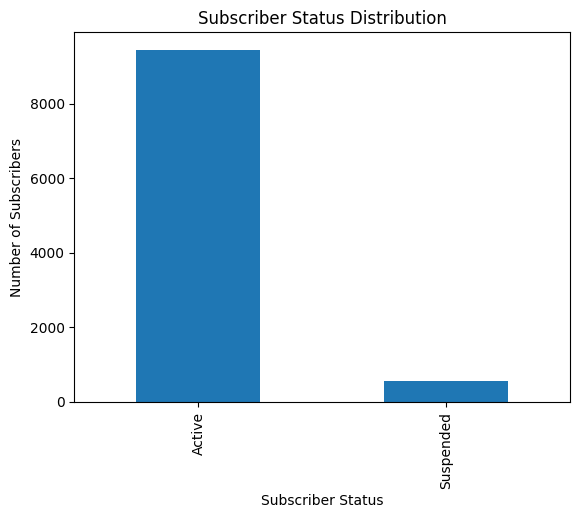

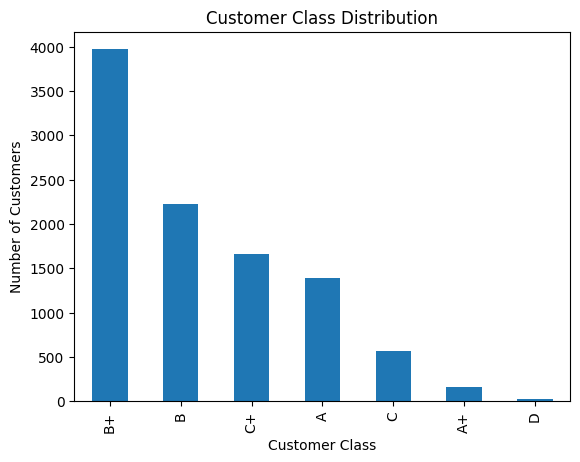

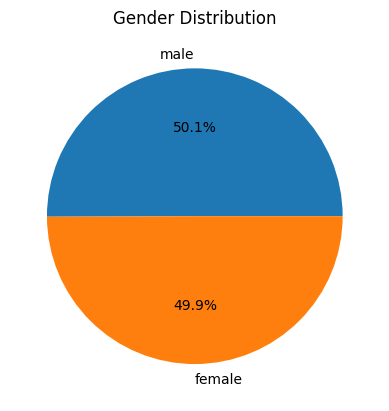

In [100]:
# ── EDA: Customer Table ──────────────────────────────────────────────────────
customer["SUBSCRIBER_STATUS"].value_counts().plot(kind="bar")

plt.title("Subscriber Status Distribution")
plt.xlabel("Subscriber Status")
plt.ylabel("Number of Subscribers")
plt.show()
#Most subscribers are Active, while only a small number belong to other subscription statuses
customer["CUSTOMER_CLASS"].value_counts().plot(kind="bar")

plt.title("Customer Class Distribution")
plt.xlabel("Customer Class")
plt.ylabel("Number of Customers")
plt.show()

customer["GENDER"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()




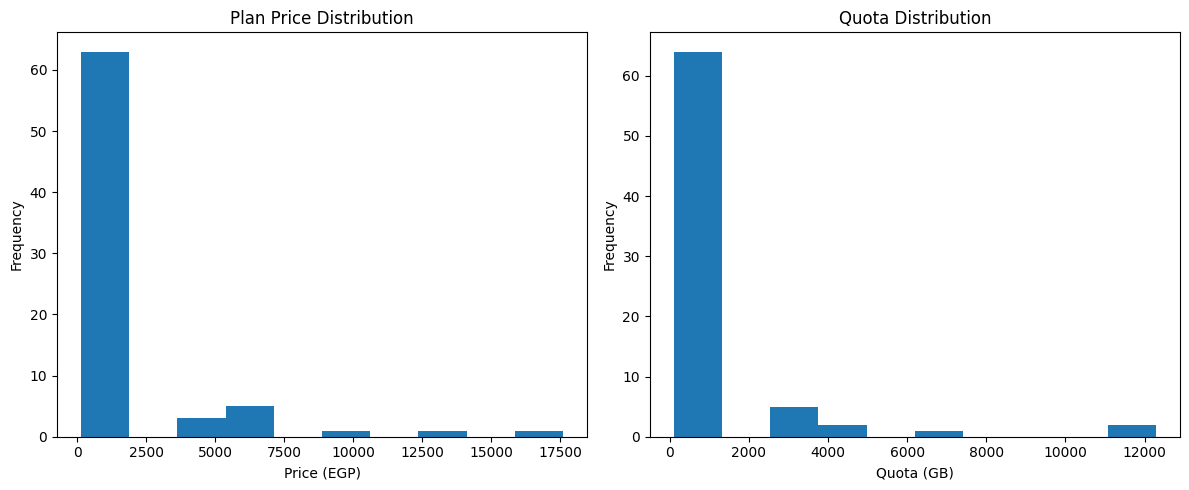

In [101]:
#EDA: plans table--------------------------------------------------

# Filter active plans
active_plans = plans[plans["PRICE_PLAN_PRICE"] > 0].copy()

# Convert QUOTA to numeric
active_plans["QUOTA"] = active_plans["QUOTA"].replace("1TB", "1024")
active_plans["QUOTA"] = active_plans["QUOTA"].astype(float)

# Create two plots side by side
plt.figure(figsize=(12,5))

# Price Plot
plt.subplot(1,2,1)
active_plans["PRICE_PLAN_PRICE"].plot(kind="hist", bins=10)
plt.title("Plan Price Distribution")
plt.xlabel("Price (EGP)")
plt.ylabel("Frequency")

# Quota Plot
plt.subplot(1,2,2)
active_plans["QUOTA"].plot(kind="hist", bins=10)
plt.title("Quota Distribution")
plt.xlabel("Quota (GB)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

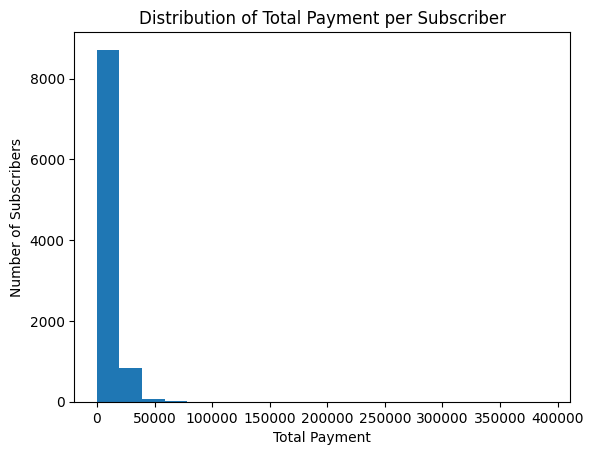

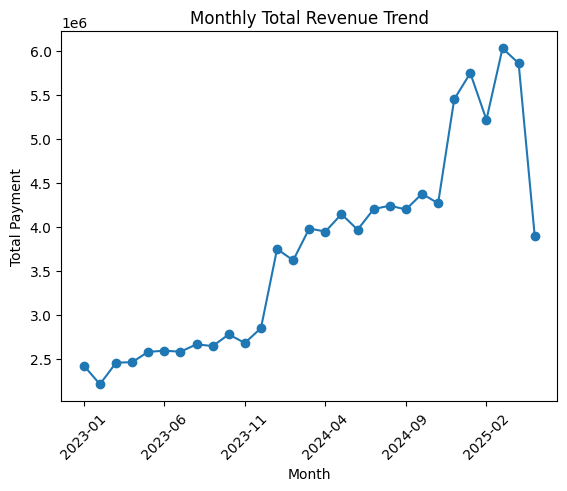

In [102]:
# ── EDA: Payments Table ──────────────────────────────────────────────────────
payments["total_payment"] = (
    payments["RENT_REVENUE"] +
    payments["OUT_BUNDLE_REVENUE"] +
    payments["CREATION_FEES_REVENUE"] +
    payments["DEVICES_REVENUE"] +
    payments["IN_BUNDLE_REVENUE"] +
    payments["ADDON_REVENUE"] +
    payments["TAX_AMOUNT"]
)
subscriber_payment = payments.groupby("SUBSCRIBER_ID#")["total_payment"].sum()

subscriber_payment.plot(kind="hist", bins=20)

plt.title("Distribution of Total Payment per Subscriber")
plt.xlabel("Total Payment")
plt.ylabel("Number of Subscribers")
plt.show()
payments["CONNECT_DATE"] = pd.to_datetime(payments["CONNECT_DATE"])

monthly_payment = payments.groupby(
    payments["CONNECT_DATE"].dt.to_period("M")
)["total_payment"].sum()

monthly_payment.index = monthly_payment.index.astype(str)

monthly_payment.plot(kind="line", marker="o")

plt.title("Monthly Total Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Payment")
plt.xticks(rotation=45)

plt.show()


---
## Step 2 — Join the Tables

### Objective
Build a single unified subscriber profile by merging all relevant tables.

### Why This Step Matters
Real-world data is never in one place. The ability to correctly join tables — using the right keys and avoiding duplicates or row explosions — is a core data engineering skill.

### What To Do
- Start from `Customer.csv` as the base table.
- Join `Subscription_Plan_Lkp` on `SUBSCRIPTION_PLAN_ID#` → adds quota, speed, price.
- Join `Network_Elements` on `SERVICE_NUMBER#` → adds technology type.
- Aggregate `Payments` per subscriber, then join on `SUBSCRIBER_ID#`.
- After each join, verify the row count has not changed unexpectedly.

> **Watch out for:** Duplicate plan IDs in the lookup table — handle them before joining to avoid inflating your row count.


In [103]:
# ── Clean Plans ───────────────────────────────────
# Check duplicate plan IDs
plans.duplicated(subset="SUBSCRIPTION_PLAN_ID#").sum()
# no duplicates plan ids were found

np.int64(0)

In [104]:
# ── Join Plans ────────────────────────────────────────────────────────────────
# Join Customer with Plans
customer_plans = customer.merge(
    plans,
    on="SUBSCRIPTION_PLAN_ID#",
    how="left"
)

# Verify row count
print("Rows before join:", customer.shape[0])
print("Rows after join:", customer_plans.shape[0])

Rows before join: 9995
Rows after join: 9995


In [105]:
# ── Join Network ──────────────────────────────────────────────────────────────
customer_plans_network = customer_plans.merge(
    network,
    on="SERVICE_NUMBER#",
    how="left"
)
print("Rows before join:", customer_plans.shape[0])
print("Rows after join:", customer_plans_network.shape[0])

Rows before join: 9995
Rows after join: 9995


In [106]:
# ── Aggregate Payments ────────────────────────────────────────────────────────

# Calculate total payment
payments["total_payment"] = (
    payments["RENT_REVENUE"] +
    payments["OUT_BUNDLE_REVENUE"] +
    payments["CREATION_FEES_REVENUE"] +
    payments["DEVICES_REVENUE"] +
    payments["IN_BUNDLE_REVENUE"] +
    payments["ADDON_REVENUE"] +
    payments["TAX_AMOUNT"]
)

# Aggregate payments per subscriber
payments_summary = payments.groupby(
    "SUBSCRIBER_ID#", as_index=False
)["total_payment"].sum()

# Join aggregated payments with the main dataset
final_data = customer_plans_network.merge(
    payments_summary,
    on="SUBSCRIBER_ID#",
    how="left"
)

# Verify row count
print("Rows before join:", customer_plans_network.shape[0])
print("Rows after join:", final_data.shape[0])

# Preview the final dataset
final_data.head()

Rows before join: 9995
Rows after join: 9995


,SUBSCRIBER_ID#,ACCOUNT_ID#,CUSTOMER_ID#,GROUP_ID#,NAME,SUBSCRIBER_STATUS,STATUS_DATE,GENDER,BIRTHDATE,ID_TYPE,...,SUBSCRIPTION_PLAN_FAMILY_START_TIME,SUBSCRIPTION_PLAN_FAMILY_END_TIME,CUSTOMER_TYPE,TECHNOLOGY_TYPE,CABIN_CODE,CENTRAL_NAME,CABIN_LAT,CABIN_LONG,GOV,total_payment
0,2207712503,111452230007712503,1107671773,NaN,ليلى العتيبي,Active,2019-01-17,female,1994-08-04,ID Card,...,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,SV,CABIN 11247,دمياط 2,31.41,31.80,دمياط,11924.0
1,2206313482,111130000088337202,1106271161,NaN,شهد القحطاني,Active,2018-01-09,female,1990-01-10,ID Card,...,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,SV,CABIN 12729,ساحل سليم الرئيسي,27.07,31.34,اسيوط,18800.0
2,132691373,107670000117446618,1011011004137519,NaN,ليلى العراقي,Active,2025-02-09,female,1993-04-21,ID Card,...,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,VDSL,CABIN 8371,طنطا 2,30.79,31.00,الغربية,2380.0
3,56271964,116480000024409877,1011011013308161,NaN,أحمد القحطاني,Active,2020-06-26,male,1999-10-03,ID Card,...,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,VDSL,CABIN 3985,الهانوفيل 1,31.10,29.77,الأسكندرية,30130.0
4,54677049,114510000121790328,1107079372,2.019910e+16,خالد السبيعي,Active,2025-01-15,male,1989-05-12,ID Card,...,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,SV,CABIN 6473,بدر,30.13,31.71,القاهرة,5270.0


---
## Step 3 — Feature Engineering

### Objective
Transform raw columns into meaningful features that help the model learn patterns.

### Why This Step Matters
Raw data rarely goes directly into a model. Feature engineering is where domain knowledge meets data science — the better your features, the better your model.

### Features To Create

| Feature | Formula | What It Captures |
|---------|---------|-----------------|
| `tenure_days` | `reference_date − ACTIVATION_DATE` | How long the subscriber has been active |
| `avg_monthly_rev` | Mean of payments per subscriber | Average spending per month |
| `addon_ratio` | `addon_total / total_revenue` | How often the subscriber exceeds their bundle |
| `price_to_quota_ratio` | `PRICE_PLAN_PRICE / QUOTA_NUM` | Cost per GB — how expensive the plan is relative to its size |

---

**Formula Details:**

**addon_ratio:**

$$\text{addon_ratio} = \frac{\text{ADDON_REVENUE}}{\text{total_revenue}}$$

*Example:* Subscriber paid 500 EGP total, 100 EGP was addon → addon_ratio = 100/500 = **0.20** (20% outside bundle)

---

**price_to_quota_ratio:**

$$\text{price_to_quota_ratio} = \frac{\text{PRICE_PLAN_PRICE}}{\text{QUOTA_NUM}}$$

*Example:* Plan costs 570 EGP for 400 GB → price_to_quota_ratio = 570/400 = **1.43 EGP per GB**

---

After creating each feature, print a `.describe()` and check for outliers or unexpected values.


In [107]:
# ── tenure_days ──────────────────────────────────────────────────────────────
# ── tenure_days & avg_monthly_rev ─────────────────────────────────────────

# Convert activation date to datetime
final_data["ACTIVATION_DATE"] = pd.to_datetime(final_data["ACTIVATION_DATE"])

# Reference date
reference_date = final_data["ACTIVATION_DATE"].max()

# Create tenure_days
final_data["tenure_days"] = (
    reference_date - final_data["ACTIVATION_DATE"]
).dt.days

# Calculate average monthly revenue per subscriber
avg_monthly_rev = payments.groupby("SUBSCRIBER_ID#")["total_payment"].mean().reset_index()

avg_monthly_rev.rename(
    columns={"total_payment": "avg_monthly_rev"},
    inplace=True
)

# Merge with final dataset
final_data = final_data.merge(
    avg_monthly_rev,
    on="SUBSCRIBER_ID#",
    how="left"
)

# Display summary statistics
print("Tenure Days")
print(final_data["tenure_days"].describe())

print("\nAverage Monthly Revenue")
print(final_data["avg_monthly_rev"].describe())

Tenure Days
count    9995.000000
mean     1695.469135
std      1234.497665
min         0.000000
25%       690.000000
50%      1556.000000
75%      2452.000000
max      7734.000000
Name: tenure_days, dtype: float64

Average Monthly Revenue
count    9632.000000
mean      341.655027
std       262.739756
min        10.000000
25%       226.707650
50%       303.333333
75%       376.666667
max      8925.000000
Name: avg_monthly_rev, dtype: float64


In [108]:
# ── addon_ratio ──────────────────────────────────────────────────────────────
# addon_ratio = addon_total / total_revenue

# Calculate addon revenue and total revenue for each subscriber
payment_summary = payments.groupby("SUBSCRIBER_ID#").agg({
    "ADDON_REVENUE": "sum",
    "total_payment": "sum"
}).reset_index()

# Create addon_ratio
payment_summary["addon_ratio"] = (
    payment_summary["ADDON_REVENUE"] /
    payment_summary["total_payment"]
)

# Merge with the final dataset
final_data = final_data.merge(
    payment_summary[["SUBSCRIBER_ID#", "addon_ratio"]],
    on="SUBSCRIBER_ID#",
    how="left"
)

# Display summary statistics
print(final_data["addon_ratio"].describe())

count    9632.000000
mean        0.028497
std         0.043661
min         0.000000
25%         0.000000
50%         0.014228
75%         0.032609
max         0.500000
Name: addon_ratio, dtype: float64


In [109]:
# ── price_to_quota_ratio ─────────────────────────────────────────────────────
# price_to_quota_ratio = PRICE_PLAN_PRICE / QUOTA_NUM (EGP per GB)

# Convert QUOTA to numeric
final_data["QUOTA_NUM"] = final_data["QUOTA"].replace("1TB", "1024")
final_data["QUOTA_NUM"] = pd.to_numeric(final_data["QUOTA_NUM"])

# Create the feature
final_data["price_to_quota_ratio"] = (
    final_data["PRICE_PLAN_PRICE"] / final_data["QUOTA_NUM"]
)

# Display summary statistics
print(final_data["price_to_quota_ratio"].describe())

count    9995.000000
mean        1.409352
std         0.632042
min         0.000000
25%         1.450000
50%         1.500000
75%         1.500000
max        44.785714
Name: price_to_quota_ratio, dtype: float64


In [110]:
# ── Summary: All Engineered Features ─────────────────────────────────────────

final_data[
    [
        "tenure_days",
        "avg_monthly_rev",
        "addon_ratio",
        "price_to_quota_ratio"
    ]
].describe()

,tenure_days,avg_monthly_rev,addon_ratio,price_to_quota_ratio
count,9995.000000,9632.000000,9632.000000,9995.000000
mean,1695.469135,341.655027,0.028497,1.409352
std,1234.497665,262.739756,0.043661,0.632042
min,0.000000,10.000000,0.000000,0.000000
25%,690.000000,226.707650,0.000000,1.450000
50%,1556.000000,303.333333,0.014228,1.500000
75%,2452.000000,376.666667,0.032609,1.500000
max,7734.000000,8925.000000,0.500000,44.785714


---
## Step 4 — Build the Target Variable

### Objective
Define the label the model will learn to predict.

### Why This Step Matters
In supervised ML, the quality of your label directly determines the quality of your model. Here, there is no pre-labeled column — you must define the business logic yourself.

### Labeling Logic

First, compute the **pay_ratio** — how much the subscriber actually pays relative to their plan price:

$$\text{pay_ratio} = \frac{\text{avg_monthly_rev}}{\text{PRICE_PLAN_PRICE}}$$

Then apply the following rules:

| Condition | Label |
|-----------|-------|
| `addon_ratio > 0.15` OR `pay_ratio > 1.30` | `Upgrade` — paying beyond their plan |
| `pay_ratio < 0.50` | `Downgrade` — consistently under-paying |
| Everything else | `Keep` — plan is a good fit |

**Examples:**

| Subscriber | Plan Price | Avg Monthly Pay | pay_ratio | addon_ratio | Label |
|-----------|-----------|----------------|-----------|-------------|-------|
| A | 400 EGP | 550 EGP | 1.375 → 137% | 0.05 | **Upgrade** |
| B | 400 EGP | 180 EGP | 0.450 → 45% | 0.01 | **Downgrade** |
| C | 400 EGP | 350 EGP | 0.875 → 87% | 0.08 | **Keep** |


---

After labeling: print the class distribution. If any class has fewer than 5% of records, discuss in a markdown cell whether this is a problem and how you would handle it.


In [111]:
# ── Compute pay_ratio ────────────────────────────────────────────────────────

# Calculate pay_ratio
final_data["pay_ratio"] = (
    final_data["avg_monthly_rev"] /
    final_data["PRICE_PLAN_PRICE"]
)

# Create the target variable
import numpy as np

conditions = [
    (final_data["addon_ratio"] > 0.15) | (final_data["pay_ratio"] > 1.30),
    (final_data["pay_ratio"] < 0.50)
]

choices = ["Upgrade", "Downgrade"]

final_data["target"] = np.select(
    conditions,
    choices,
    default="Keep"
)

# Check the new features
print(final_data[["pay_ratio", "target"]].head())

   pay_ratio   target
0   1.113352     Keep
1   1.421013  Upgrade
2   2.051724  Upgrade
3   1.816154  Upgrade
4        inf  Upgrade


target
Upgrade      5089
Keep         4874
Downgrade      32
Name: count, dtype: int64

Percentage Distribution:
target
Upgrade      50.915458
Keep         48.764382
Downgrade     0.320160
Name: proportion, dtype: float64


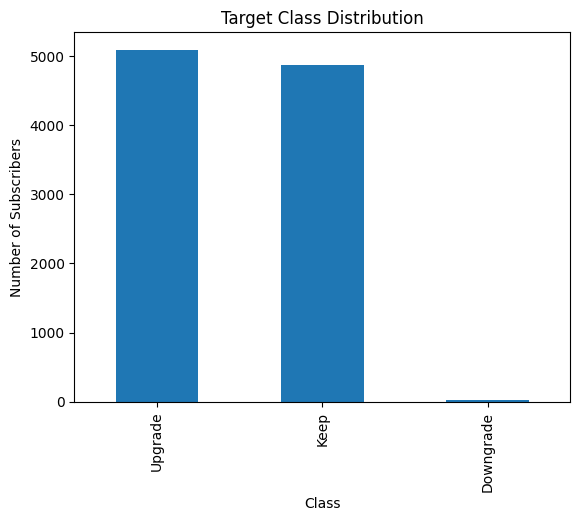

In [112]:
# ── Class Distribution ────────────────────────────────────────────────────────

print(final_data["target"].value_counts())

print("\nPercentage Distribution:")
print(final_data["target"].value_counts(normalize=True) * 100)
import matplotlib.pyplot as plt

final_data["target"].value_counts().plot(kind="bar")

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Subscribers")
plt.show()

---
## Step 5 — Train & Compare Models

### Objective
Train multiple classifiers and understand the tradeoffs between them.

### Why This Step Matters
No single model is always best. A good data scientist knows when to use a simple interpretable model versus a complex one — and can justify that choice to a non-technical business stakeholder.

### Models To Train

| Model | Why |
|-------|-----|
| **Logistic Regression** | Your baseline — fast, interpretable, good for linear relationships |
| **Random Forest** | Handles non-linearity and feature interactions well |
| **Gradient Boosting** | Typically stronger performance but slower to train |

### Rules
- Use the same train/test/val split for all models `random_state=42`
- Print the Classification Report for each model
- Note any class where the model performs poorly and explain why in a markdown cell


In [113]:
# ── Select Features & Filter ─────────────────────────────────────────────────

features = [
    "tenure_days",
    "avg_monthly_rev",
    "addon_ratio",
    "price_to_quota_ratio",
    "GENDER",
    "CUSTOMER_CLASS",
    "TECHNOLOGY_TYPE"
]

X = final_data[features]
y = final_data["target"]

print(X.head())
print(y.value_counts())

   tenure_days  avg_monthly_rev  addon_ratio  price_to_quota_ratio  GENDER  \
0         2311       233.803922     0.070614                  1.50  female   
1         2684       298.412698     0.059574                  1.50  female   
2           94       595.000000     0.063025                  1.45  female   
3         1889       381.392405     0.346664                  1.50    male   
4         1953       292.777778     0.016129                  0.00    male   

  CUSTOMER_CLASS TECHNOLOGY_TYPE  
0             B+              SV  
1             B+              SV  
2              C            VDSL  
3              A            VDSL  
4             C+              SV  
target
Upgrade      5089
Keep         4874
Downgrade      32
Name: count, dtype: int64


In [114]:
# ── Handle Missing Values ─────────────────────────────────────────────────────
# Numerical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

print(X.isnull().sum())

tenure_days             0
avg_monthly_rev         0
addon_ratio             0
price_to_quota_ratio    0
GENDER                  0
CUSTOMER_CLASS          0
TECHNOLOGY_TYPE         0
dtype: int64


/tmp/ipykernel_704/1853828669.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[num_cols] = X[num_cols].fillna(X[num_cols].median())
/tmp/ipykernel_704/1853828669.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])


In [115]:
# ── Encode Categorical Features ──────────────────────────────────────────────# ── Encode Categorical Features ─────────────────────────────────────────

X = pd.get_dummies(
    X,
    columns=["GENDER", "CUSTOMER_CLASS", "TECHNOLOGY_TYPE"],
    drop_first=True
)

print(X.head())

   tenure_days  avg_monthly_rev  addon_ratio  price_to_quota_ratio  \
0         2311       233.803922     0.070614                  1.50   
1         2684       298.412698     0.059574                  1.50   
2           94       595.000000     0.063025                  1.45   
3         1889       381.392405     0.346664                  1.50   
4         1953       292.777778     0.016129                  0.00   

   GENDER_male  CUSTOMER_CLASS_A+  CUSTOMER_CLASS_B  CUSTOMER_CLASS_B+  \
0        False              False             False               True   
1        False              False             False               True   
2        False              False             False              False   
3         True              False             False              False   
4         True              False             False              False   

   CUSTOMER_CLASS_C  CUSTOMER_CLASS_C+  CUSTOMER_CLASS_D  TECHNOLOGY_TYPE_ESL  \
0             False              False             Fa

In [116]:
# ── Train / Test Split ───────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7996, 15)
(1999, 15)


In [117]:
# ── Model 1: Logistic Regression (Baseline) ──────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

#Logistic Regression achieved an accuracy of approximately **74%**. It performed reasonably well for the **Keep** and **Upgrade** classes but failed to identify any **Downgrade** subscribers. This is mainly due to the severe class imbalance, where the Downgrade class contains very few samples compared to the other classes.

              precision    recall  f1-score   support

   Downgrade       0.00      0.00      0.00         6
        Keep       0.71      0.79      0.75       975
     Upgrade       0.78      0.69      0.73      1018

    accuracy                           0.74      1999
   macro avg       0.49      0.50      0.49      1999
weighted avg       0.74      0.74      0.74      1999



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

In [118]:
# ── Model 2: Random Forest ───────────────────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))


#Random Forest achieved an accuracy of approximately **98%**, showing a significant improvement over Logistic Regression. It classified the **Keep** and **Upgrade** classes very accurately but still failed to correctly predict the **Downgrade** class because of the extremely small number of Downgrade examples in the dataset.

              precision    recall  f1-score   support

   Downgrade       0.00      0.00      0.00         6
        Keep       0.98      0.98      0.98       975
     Upgrade       0.98      0.99      0.98      1018

    accuracy                           0.98      1999
   macro avg       0.65      0.65      0.65      1999
weighted avg       0.98      0.98      0.98      1999



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [119]:
# ── Model 3: Gradient Boosting ───────────────────────────────────────────────

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print(classification_report(y_test, y_pred_gb))


#Gradient Boosting achieved the best performance with an accuracy of approximately **99%**. Unlike the other models, it successfully identified most **Downgrade** subscribers while maintaining excellent performance on the **Keep** and **Upgrade** classes. This indicates that Gradient Boosting handled the complex relationships in the data more effectively.

              precision    recall  f1-score   support

   Downgrade       0.56      0.83      0.67         6
        Keep       1.00      0.99      0.99       975
     Upgrade       0.99      0.99      0.99      1018

    accuracy                           0.99      1999
   macro avg       0.85      0.94      0.88      1999
weighted avg       0.99      0.99      0.99      1999



---
## Step 6 — Evaluate

### Objective
Measure model performance beyond just accuracy.


In [120]:
# ── Model Comparison ─────────────────────────────────────────────────────────

from sklearn.metrics import accuracy_score

logistic_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, y_pred_rf)
gb_acc = accuracy_score(y_test, y_pred_gb)

print("Logistic Regression Accuracy :", round(logistic_acc, 4))
print("Random Forest Accuracy       :", round(rf_acc, 4))
print("Gradient Boosting Accuracy   :", round(gb_acc, 4))

Logistic Regression Accuracy : 0.7394
Random Forest Accuracy       : 0.979
Gradient Boosting Accuracy   : 0.9925


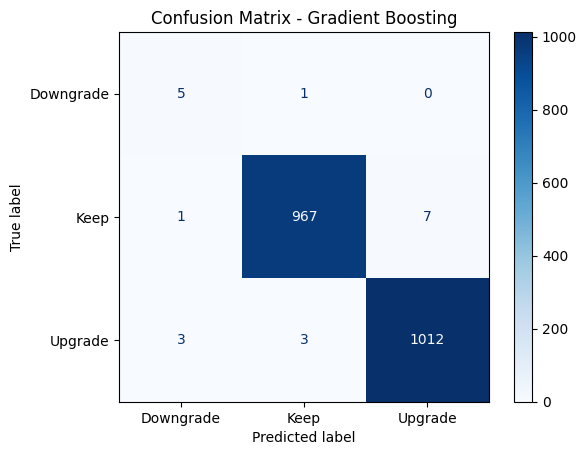

In [121]:
# ── Confusion Matrix (Best Model) ────────────────────────────────────────────

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=gb.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

---
## Step 7 — Business Impact

### Objective
Translate model predictions into actionable business recommendations.



In [122]:
# ── Predictions on Full Dataset ──────────────────────────────────────────────

# Predict on the full dataset
final_data["Predicted_Action"] = gb.predict(X)

# Display prediction counts
print(final_data["Predicted_Action"].value_counts())

# Preview results
final_data[["SUBSCRIBER_ID#", "Predicted_Action"]].head()

Predicted_Action
Upgrade      5104
Keep         4856
Downgrade      35
Name: count, dtype: int64


,SUBSCRIBER_ID#,Predicted_Action
0,2207712503,Keep
1,2206313482,Upgrade
2,132691373,Upgrade
3,56271964,Upgrade
4,54677049,Upgrade


In [123]:
# ── Revenue Opportunity ──────────────────────────────────────────────────────

upgrade_customers = final_data[
    final_data["Predicted_Action"] == "Upgrade"
]

print("Number of Upgrade Candidates:", len(upgrade_customers))

potential_revenue = upgrade_customers["PRICE_PLAN_PRICE"].sum()

print("Current Revenue from Upgrade Candidates:", potential_revenue)


Number of Upgrade Candidates: 5104
Current Revenue from Upgrade Candidates: 1222570.0


In [124]:
# ── Upgrade Candidates Profile ───────────────────────────────────────────────

upgrade_profile = upgrade_customers[
    [
        "CUSTOMER_CLASS",
        "TECHNOLOGY_TYPE",
        "PRICE_PLAN_PRICE",
        "avg_monthly_rev",
        "addon_ratio"
    ]
]

print(upgrade_profile.describe(include="all"))

upgrade_profile.head()

       CUSTOMER_CLASS TECHNOLOGY_TYPE  PRICE_PLAN_PRICE  avg_monthly_rev  \
count            5104            5078       5104.000000      5095.000000   
unique              7               4               NaN              NaN   
top                B+            VDSL               NaN              NaN   
freq             1765            3257               NaN              NaN   
mean              NaN             NaN        239.531740       399.949888   
std               NaN             NaN        144.833779       202.230682   
min               NaN             NaN          0.000000        10.000000   
25%               NaN             NaN        210.000000       303.571429   
50%               NaN             NaN        210.000000       330.476190   
75%               NaN             NaN        290.000000       441.590909   
max               NaN             NaN       5830.000000      3448.309859   

        addon_ratio  
count   5095.000000  
unique          NaN  
top             NaN  

,CUSTOMER_CLASS,TECHNOLOGY_TYPE,PRICE_PLAN_PRICE,avg_monthly_rev,addon_ratio
1,B+,SV,210.0,298.412698,0.059574
2,C,VDSL,290.0,595.000000,0.063025
3,A,VDSL,210.0,381.392405,0.346664
4,C+,SV,0.0,292.777778,0.016129
6,B+,VDSL,210.0,307.826087,0.000000
